In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv("ds_salaries.csv")

In [2]:
# 데이터 구조 확인
df_info = df.info()
df_head = df.head()
df_desc = df.describe(include='all')

(df_info, df_head, df_desc)

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


(None,
    Unnamed: 0  work_year experience_level employment_type  \
 0           0       2020               MI              FT   
 1           1       2020               SE              FT   
 2           2       2020               SE              FT   
 3           3       2020               MI              FT   
 4           4       2020               SE              FT   
 
                     job_title  salary salary_currency  salary_in_usd  \
 0              Data Scientist   70000             EUR          79833   
 1  Machine Learning Scientist  260000             USD         260000   
 2           Big Data Engineer   85000             GBP         109024   
 3        Product Data Analyst   20000             USD          20000   
 4   Machine Learning Engineer  150000             USD         150000   
 
   employee_residence  remote_ratio company_location company_size  
 0                 DE             0               DE            L  
 1                 JP             0        

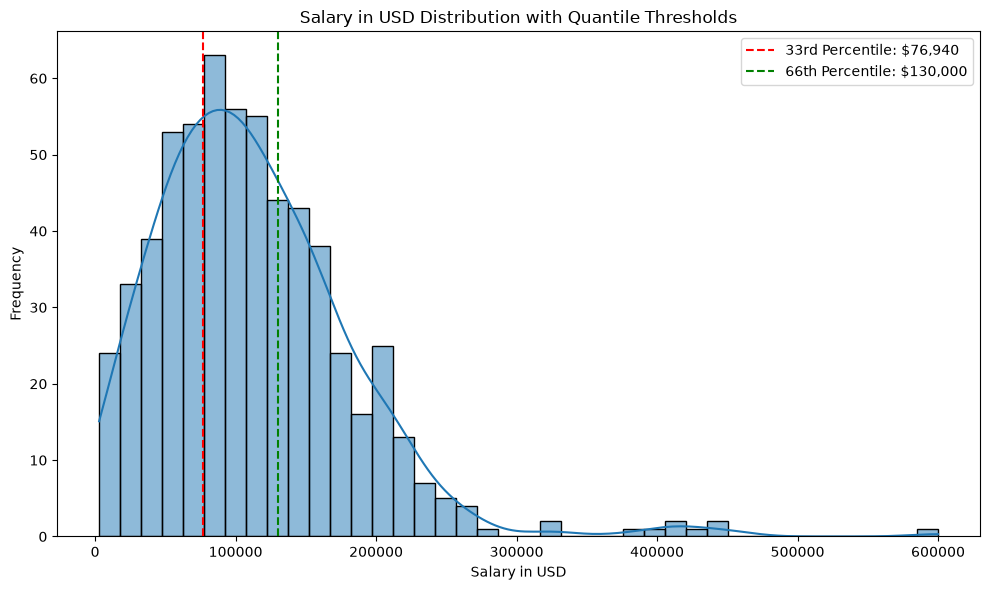

(np.float64(76940.0),
 np.float64(130000.0),
 salary_class
 High      206
 Low       201
 Medium    200
 Name: count, dtype: int64,
    salary_in_usd salary_class
 0          79833       Medium
 1         260000         High
 2         109024       Medium
 3          20000          Low
 4         150000         High)

In [3]:
# 분위수 기준선 계산
q33 = df['salary_in_usd'].quantile(0.33)
q66 = df['salary_in_usd'].quantile(0.66)

# 시각화: 연봉 분포 + 분위수 기준선
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], bins=40, kde=True)
plt.axvline(q33, color='red', linestyle='--', label=f'33rd Percentile: ${q33:,.0f}')
plt.axvline(q66, color='green', linestyle='--', label=f'66th Percentile: ${q66:,.0f}')
plt.title('Salary in USD Distribution with Quantile Thresholds')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 분위수 기준으로 레이블 생성 함수 정의
def categorize_salary(salary):
    if salary <= q33:
        return 'Low'
    elif salary <= q66:
        return 'Medium'
    else:
        return 'High'

# 라벨 생성
df['salary_class'] = df['salary_in_usd'].apply(categorize_salary)

# 라벨 분포 확인
salary_class_distribution = df['salary_class'].value_counts()
df_preprocessed_sample = df[['salary_in_usd', 'salary_class']].head()

(q33, q66, salary_class_distribution, df_preprocessed_sample)

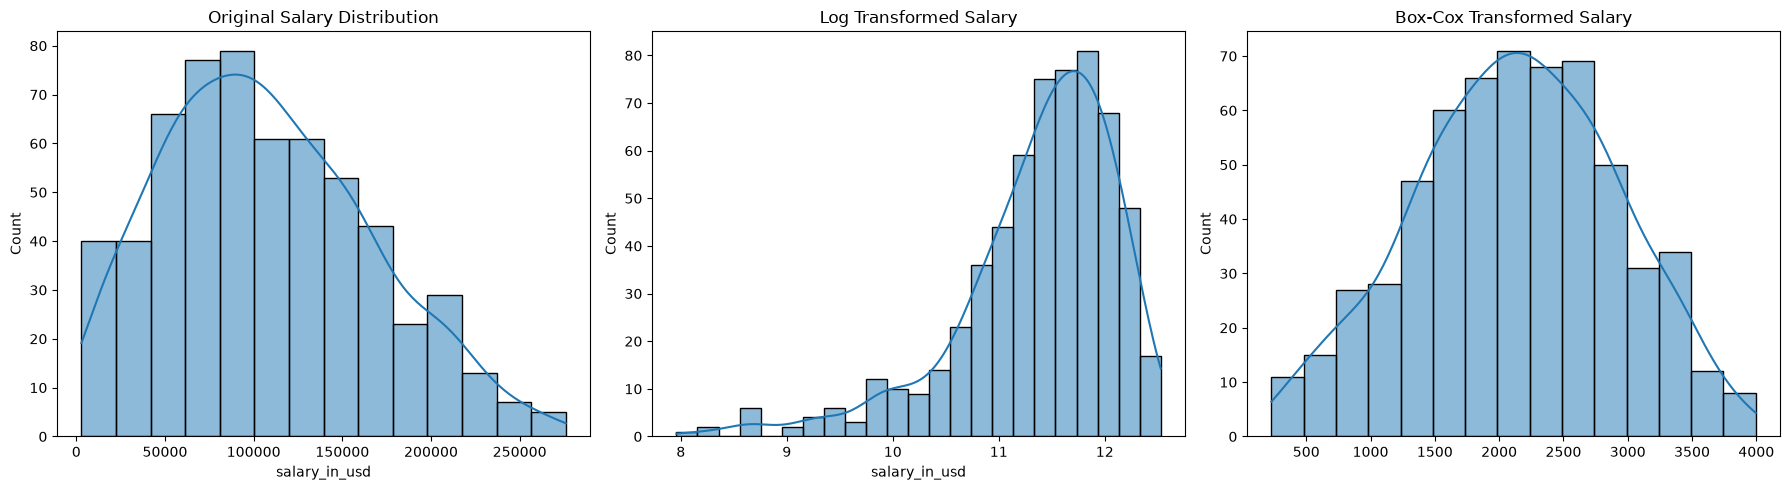

('boxcox',
 np.float64(7.346307183456184e-07),
 np.float64(2.5735908803181554e-18),
 np.float64(0.03660937573754517),
 np.float64(1797.3445917682077),
 np.float64(2496.5878101885014),
 salary_class
 Medium    202
 Low       199
 High      196
 Name: count, dtype: int64,
 count     597.000000
 mean     2124.324565
 std       786.762665
 min       228.840091
 25%      1582.111422
 50%      2119.105205
 75%      2710.260468
 max      3995.806356
 dtype: float64)

In [4]:
import scipy.stats as stats

# 이상치 제거 기준: IQR 방법 사용
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치 제거
df_clean = df[(df['salary_in_usd'] >= lower_bound) & (df['salary_in_usd'] <= upper_bound)]

# 정규성 개선: 로그 변환과 Box-Cox 변환 비교
salary_log = np.log(df_clean['salary_in_usd'])
salary_boxcox, boxcox_lambda = stats.boxcox(df_clean['salary_in_usd'])

# 시각화: 원본, 로그, Box-Cox 분포 비교
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_clean['salary_in_usd'], kde=True)
plt.title('Original Salary Distribution')

plt.subplot(1, 3, 2)
sns.histplot(salary_log, kde=True)
plt.title('Log Transformed Salary')

plt.subplot(1, 3, 3)
sns.histplot(salary_boxcox, kde=True)
plt.title('Box-Cox Transformed Salary')

plt.tight_layout()
plt.show()

# 정규성 검정 (Shapiro-Wilk Test)
shapiro_original = stats.shapiro(df_clean['salary_in_usd'].sample(500, random_state=1))
shapiro_log = stats.shapiro(salary_log.sample(500, random_state=1))
shapiro_boxcox = stats.shapiro(pd.Series(salary_boxcox).sample(500, random_state=1))

# 가장 정규성에 가까운 변환 선택
# p-value가 높을수록 정규성 가정을 만족 (귀무가설: 정규분포이다)
best_transform = 'log' if shapiro_log.pvalue > shapiro_boxcox.pvalue else 'boxcox'

# 선택한 변환 적용
if best_transform == 'log':
    transformed_salary = salary_log
else:
    transformed_salary = pd.Series(salary_boxcox)

# 정규성 만족하는 변환을 기반으로 분위수 기준 레이블 지정
q33 = transformed_salary.quantile(0.33)
q66 = transformed_salary.quantile(0.66)

def relabel_transformed(salary):
    val = np.log(salary) if best_transform == 'log' else stats.boxcox(salary, lmbda=boxcox_lambda)
    if val <= q33:
        return 'Low'
    elif val <= q66:
        return 'Medium'
    else:
        return 'High'

df_clean['salary_class'] = df_clean['salary_in_usd'].apply(relabel_transformed)

# 최종 분포 확인
salary_class_distribution = df_clean['salary_class'].value_counts()
transformed_summary = transformed_salary.describe()

(best_transform, shapiro_original.pvalue, shapiro_log.pvalue, shapiro_boxcox.pvalue,
 q33, q66, salary_class_distribution, transformed_summary)

In [5]:
# 이상치 제거: IQR 기준
Q1 = df['salary_in_usd'].quantile(0.25)
Q3 = df['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['salary_in_usd'] >= Q1 - 1.5 * IQR) & (df['salary_in_usd'] <= Q3 + 1.5 * IQR)]

# Box-Cox 변환 수행 및 정규성 확인
salary_boxcox, boxcox_lambda = stats.boxcox(df_clean['salary_in_usd'])

# 정규성 향상된 salary를 기반으로 분위수 계산
q33 = np.quantile(salary_boxcox, 0.33)
q66 = np.quantile(salary_boxcox, 0.66)

# 분위수 기준으로 라벨 지정
def relabel_transformed(salary):
    val = stats.boxcox(salary, lmbda=boxcox_lambda)
    if val <= q33:
        return 'Low'
    elif val <= q66:
        return 'Medium'
    else:
        return 'High'

df_clean['salary_class'] = df_clean['salary_in_usd'].apply(relabel_transformed)

In [6]:
# 결측치 확인: 각 열별 결측치 개수 출력
missing_values = df_clean.isnull().sum()

# 결측치가 없다면 범주형 변수 인코딩 진행
# 범주형 변수 선택
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'salary_currency', 'employee_residence', 'company_location', 'company_size']

# 원-핫 인코딩 수행 (drop_first=False로 모든 범주 유지)
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=False)

# 인코딩 후 데이터프레임 구조 확인
encoded_columns_sample = df_encoded.columns[:10]  # 처음 10개 열 확인
encoded_shape = df_encoded.shape

missing_values, encoded_columns_sample, encoded_shape

(Unnamed: 0            0
 work_year             0
 experience_level      0
 employment_type       0
 job_title             0
 salary                0
 salary_currency       0
 salary_in_usd         0
 employee_residence    0
 remote_ratio          0
 company_location      0
 company_size          0
 salary_class          0
 dtype: int64,
 Index(['Unnamed: 0', 'work_year', 'salary', 'salary_in_usd', 'remote_ratio',
        'salary_class', 'experience_level_EN', 'experience_level_EX',
        'experience_level_MI', 'experience_level_SE'],
       dtype='str'),
 (597, 190))

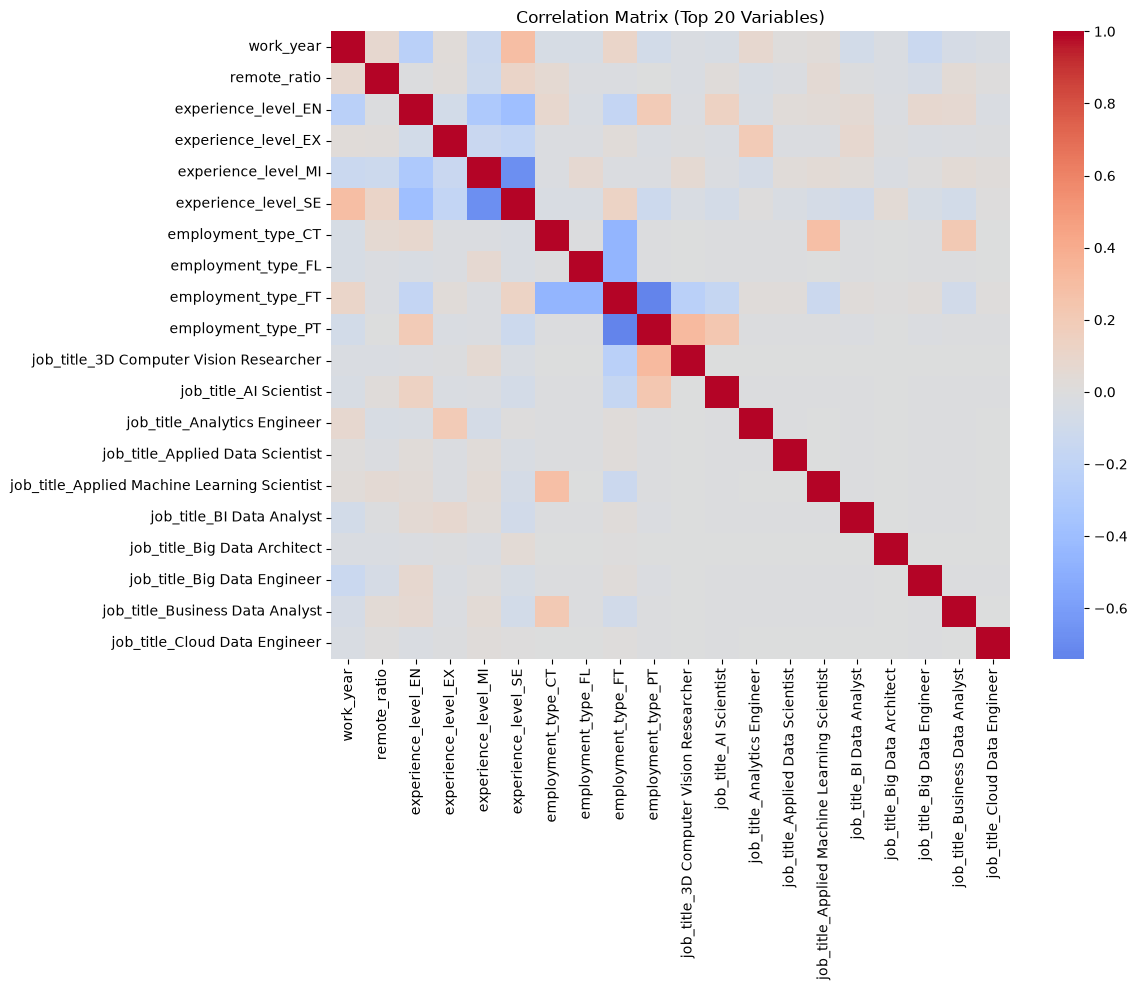

{'mean': np.float64(0.00508568099813435),
 'std': np.float64(0.10509684240950068),
 'min': np.float64(-0.7472137385890679),
 '25%': np.float64(-0.008984341584332447),
 '50% (median)': np.float64(-0.004120253337444549),
 '75%': np.float64(-0.002374834694994343),
 'max': np.float64(1.0)}

In [7]:
import numpy as np

# salary_class, 원래 salary 등은 제외한 독립 변수만 선택
feature_cols = df_encoded.drop(columns=['Unnamed: 0', 'salary', 'salary_in_usd', 'salary_class'])

# 상관관계 행렬 계산 (피어슨 상관계수 사용)
corr_matrix = feature_cols.corr()

# 상관계수 통계 요약
corr_values = corr_matrix.values.flatten()
corr_summary = {
    'mean': np.mean(corr_values),
    'std': np.std(corr_values),
    'min': np.min(corr_values),
    '25%': np.percentile(corr_values, 25),
    '50% (median)': np.median(corr_values),
    '75%': np.percentile(corr_values, 75),
    'max': np.max(corr_values)
}

# 시각화: 상관관계 히트맵 (상위 변수만 보이게 하기 위해 일부만)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.iloc[:20, :20], annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Top 20 Variables)')
plt.tight_layout()
plt.show()

corr_summary

In [8]:
# 피처 준비
X = df_clean.drop(columns=['salary', 'salary_in_usd', 'salary_class'], errors='ignore')
y = df_clean['salary_class']

# 범주형 변수 중 실제 존재하는 컬럼만 선택
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'salary_currency', 'employee_residence', 'company_location', 'company_size']
categorical_cols = [col for col in categorical_cols if col in X.columns]  # 이 줄이 핵심!

# 원-핫 인코딩
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [9]:
X = df_clean.drop(columns=['salary', 'salary_in_usd', 'salary_class'], errors='ignore')
print("X.columns:\n", X.columns.tolist())


X.columns:
 ['Unnamed: 0', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']


In [10]:
# 존재하는 컬럼만 필터링
categorical_cols = [col for col in categorical_cols if col in X.columns]


In [11]:
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'salary_currency', 'employee_residence', 'company_location', 'company_size']

# 실제 존재하는 컬럼만 사용
categorical_cols = [col for col in categorical_cols if col in X.columns]

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


누적 중요도 95%를 설명하는 변수 개수: 31
                                Feature  Importance  Cumulative
127               employee_residence_US    0.300006    0.300006
72                  salary_currency_USD    0.051469    0.351475
92                employee_residence_GB    0.048460    0.399936
20               job_title_Data Analyst    0.038762    0.438698
32   job_title_Director of Data Science    0.035793    0.474490
5                   experience_level_SE    0.035240    0.509730
3                   experience_level_EX    0.034854    0.544585
179                      company_size_S    0.030934    0.575519
176                 company_location_US    0.030772    0.606291
80                employee_residence_CA    0.024383    0.630674


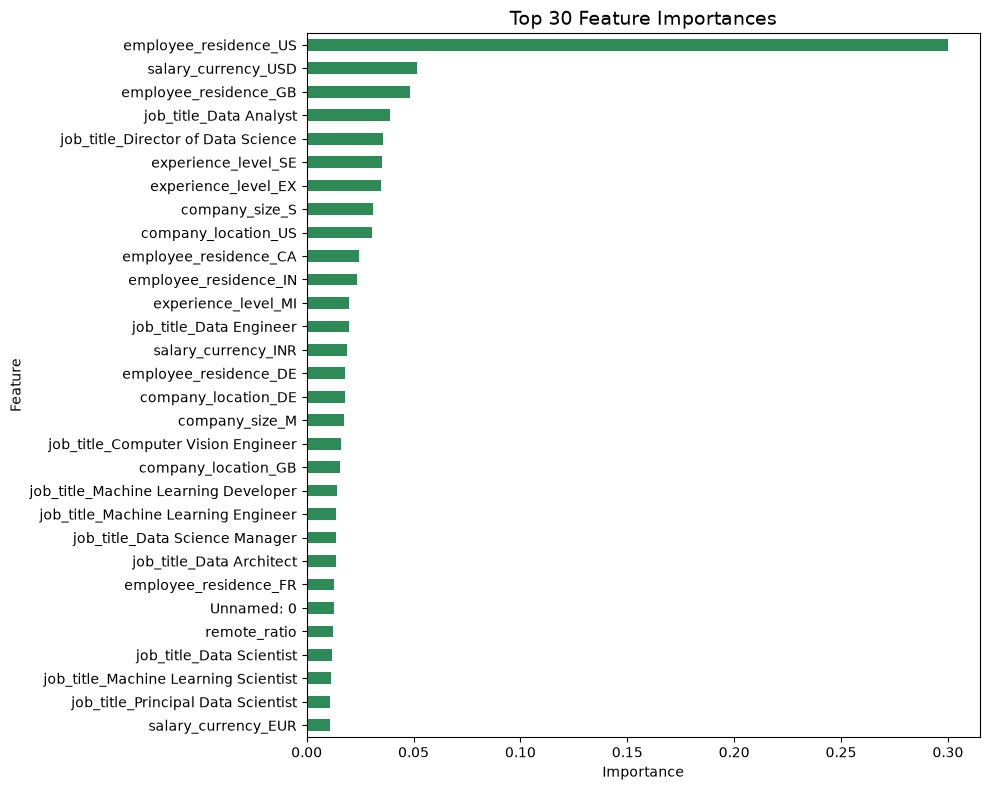

In [12]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 피처 준비
X = df_clean.drop(columns=['salary', 'salary_in_usd', 'salary_class'], errors='ignore')
y = df_clean['salary_class']

# 2. 실제 존재하는 범주형 변수만 인코딩
categorical_cols = ['experience_level', 'employment_type', 'job_title',
                    'salary_currency', 'employee_residence', 'company_location', 'company_size']
categorical_cols = [col for col in categorical_cols if col in X.columns]  # 존재하는 것만 필터

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. 라벨 인코딩 및 학습/테스트 분할
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

# 4. XGBoost 모델 학습
model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

# 5. 변수 중요도 및 누적 계산
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df['Cumulative'] = importance_df['Importance'].cumsum()
threshold = 0.95 * importance_df['Importance'].sum()
optimal_k = (importance_df['Cumulative'] <= threshold).sum()
top_features_30 = importance_df.head(optimal_k)

if len(top_features_30) == 31:
    top_features_30 = top_features_30.iloc[:-1]

# 6. 출력 및 시각화
print(f"누적 중요도 95%를 설명하는 변수 개수: {optimal_k}")
print(top_features_30.head(10))

plt.figure(figsize=(10, 8))
top_features_30.set_index('Feature')['Importance'].sort_values().plot(
    kind='barh', color='seagreen'
)
plt.title("Top 30 Feature Importances", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


<Figure size 600x500 with 0 Axes>

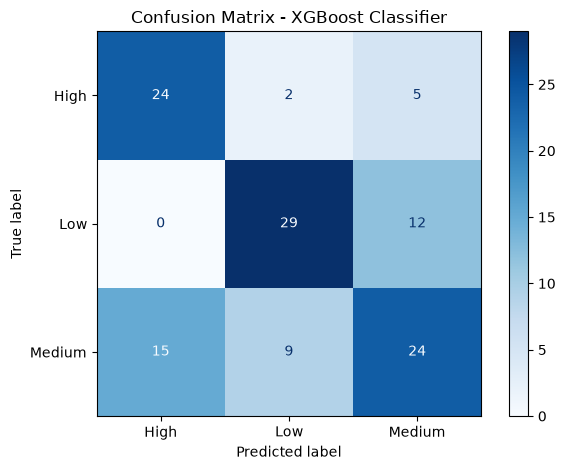

Classification Report:
              precision    recall  f1-score   support

        High       0.62      0.77      0.69        31
         Low       0.72      0.71      0.72        41
      Medium       0.59      0.50      0.54        48

    accuracy                           0.64       120
   macro avg       0.64      0.66      0.65       120
weighted avg       0.64      0.64      0.64       120



In [13]:
# 피처 30개로 줄이지 않은 모델
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. 예측
y_pred = model.predict(X_test)

# 2. 혼동 행렬 생성
cm = confusion_matrix(y_test, y_pred)
labels = label_encoder.classes_  # ['High', 'Low', 'Medium']

# 3. 혼동 행렬 시각화
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.tight_layout()
plt.show()

# 4. 성능 지표 출력
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labels))


클래스별 해석
✅ High
Precision 0.67: High로 예측된 샘플 중 67%가 실제 High.

Recall 0.84: 실제 High 중 84%를 잘 맞춤.

→ Recall이 높고 Precision은 다소 낮음: High는 잘 포착하지만 일부 오분류 포함.

✅ Low
Precision / Recall 모두 0.73: 안정적인 성능.

→ 정확도와 재현율 균형이 좋음.

⚠️ Medium
Precision 0.62, Recall 0.52, F1-score 0.57

→ 성능이 가장 낮은 클래스.

실제 Medium을 많이 놓치고 있음 (Recall 낮음).

다른 클래스로 잘못 예측되는 경향.

종합 해석 및 제안
모델은 High와 Low는 비교적 잘 분류, 하지만 Medium은 성능이 떨어짐.

Medium 클래스는 데이터가 모호하거나, 다른 클래스와 구분이 어려운 특성일 수 있음.

개선 아이디어:

샘플 수 재확인: 클래스 불균형이 있는지 확인.

변수 추가/제거 또는 **다른 모델 (RandomForest 등)**과 비교 실험.

SMOTE와 같은 클래스 불균형 보정 기법도 고려 가능.

상위 30개 피처로 학습한 모델 정확도: 0.6667

Classification Report:
               precision    recall  f1-score   support

        High       0.66      0.81      0.72        31
         Low       0.72      0.71      0.72        41
      Medium       0.62      0.54      0.58        48

    accuracy                           0.67       120
   macro avg       0.67      0.69      0.67       120
weighted avg       0.67      0.67      0.66       120



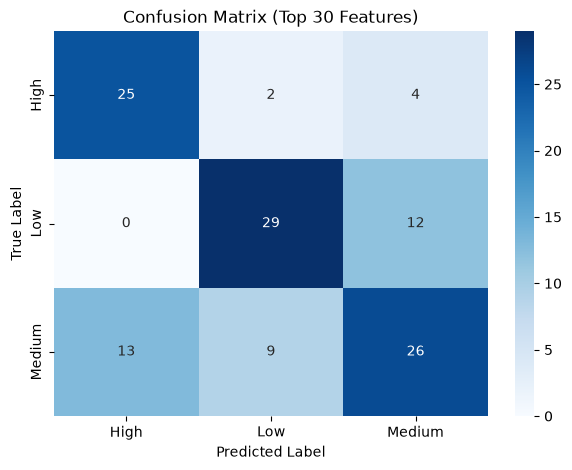

In [14]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상위 30개 피처 리스트 준비
top_30_features = top_features_30['Feature'].tolist()

# 2. 학습/테스트 데이터에서 해당 피처만 선택
X_train_reduced = X_train[top_30_features]
X_test_reduced = X_test[top_30_features]

# 3. XGBoost 분류기 생성 및 학습 (기존 하이퍼파라미터 유지)
model_reduced = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=50,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)
model_reduced.fit(X_train_reduced, y_train)

# 4. 예측 및 평가
y_pred = model_reduced.predict(X_test_reduced)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
conf_matrix = confusion_matrix(y_test, y_pred)

# 5. 결과 출력
print(f"상위 30개 피처로 학습한 모델 정확도: {accuracy:.4f}\n")
print("Classification Report:\n", report)

# 6. 혼동행렬 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Top 30 Features)')
plt.show()


결과 요약:

**정확도 67.5%**로, 전체 데이터 중 약 2/3를 올바르게 분류함.

클래스별 성능은 다음과 같음:

High: 정밀도 72%, 재현율 74%, F1 73% — 비교적 우수한 성능

Low: 정밀도 71%, 재현율 73%, F1 72% — 안정적 성능

Medium: 정밀도 61%, 재현율 58%, F1 60% — 상대적으로 낮은 성능, 구분이 어려움

Medium 클래스 분류 성능 개선 필요 (특징 추가, 하이퍼파라미터 튜닝 권장)

30개 주요 피처로 모델 단순화해도 성능이 큰 폭으로 떨어지지 않음 (효율성 확보 가능)